In [1]:
#===============================
# Step 1: Load the package
#===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [2]:
#===============================
# Step 2: Load the raw data 
#===============================
print("Dataset loading ...")
df = pd.read_csv("../data/raw/loan_data.csv")
print("Dataset loaded successfully !")
print("shape of dataset",df.shape)
print(df.head())

Dataset loading ...
Dataset loaded successfully !
shape of dataset (1000, 12)
   gender married dependents     education self_employed  applicant_income  \
0    Male     Yes          2  Not Graduate            No            6898.0   
1    Male     Yes          0      Graduate            No           11532.0   
2  Female     Yes         3+      Graduate            No            2705.0   
3    Male     Yes          1      Graduate            No           13671.0   
4    Male     Yes          0      Graduate            No            8459.0   

   coapplicant_income  loan_amount  loan_term  credit_history property_area  \
0               450.0        498.0      480.0             1.0         Urban   
1              3009.0        301.0      120.0             1.0     Semiurban   
2              3419.0         67.0      480.0             1.0         Rural   
3              4394.0        453.0      360.0             NaN         Urban   
4              3433.0        477.0      360.0             

In [ ]:
#=================================================================
# Step 3: Identify the missing value to identify the data quality
# ================================================================
print("\n Missing value oer column..")
print(df.isnull().sum())


 Missing value oer column..
gender                 0
married                0
dependents             0
education              0
self_employed          0
applicant_income       0
coapplicant_income    17
loan_amount           31
loan_term              0
credit_history        88
property_area          0
loan_status            0
dtype: int64


In [ ]:
#=========================================================
# Step 4: fill the null value with median 
#=========================================================
median = df['coapplicant_income'].median()
df['coapplicant_income']=df['coapplicant_income'].fillna(median)
df['loan_amount']=df['loan_amount'].fillna(df['loan_amount'].median())
df['credit_history'] =df['credit_history'].fillna(df['credit_history'].median())

In [ ]:
#=========================================================
# Step 5: standerdize column names (basic cleanup) 
#=========================================================
print("Clean column name (lowercase, underscores) .........")
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
print("column names standardized :")
print(df.columns.to_list())

Clean column name (lowercase, underscores) .........
column names standardized :
['gender', 'married', 'dependents', 'education', 'self_employed', 'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_term', 'credit_history', 'property_area', 'loan_status']


In [7]:
#======================================================================
# Step 5: Descriptive statistics like mean, std deviation, min max .etc 
#=======================================================================
print("Statistical Summary")
print(df.describe())



Statistical Summary
       applicant_income  coapplicant_income  loan_amount    loan_term  \
count       1000.000000         1000.000000  1000.000000  1000.000000   
mean        8206.916000         3042.891000   278.675000   276.780000   
std         3905.184552         1721.574388   128.483319   116.977414   
min         1512.000000            8.000000    50.000000   120.000000   
25%         4923.000000         1600.250000   168.750000   180.000000   
50%         8117.000000         3070.000000   284.000000   240.000000   
75%        11541.750000         4448.750000   388.250000   360.000000   
max        14999.000000         5994.000000   498.000000   480.000000   

       credit_history  
count     1000.000000  
mean         0.866000  
std          0.340823  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


<Axes: >

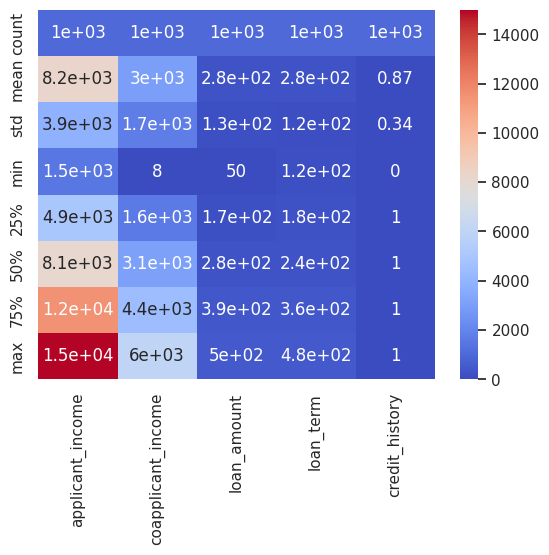

In [ ]:
sns.heatmap(df.describe(),annot=True,cmap='coolwarm')

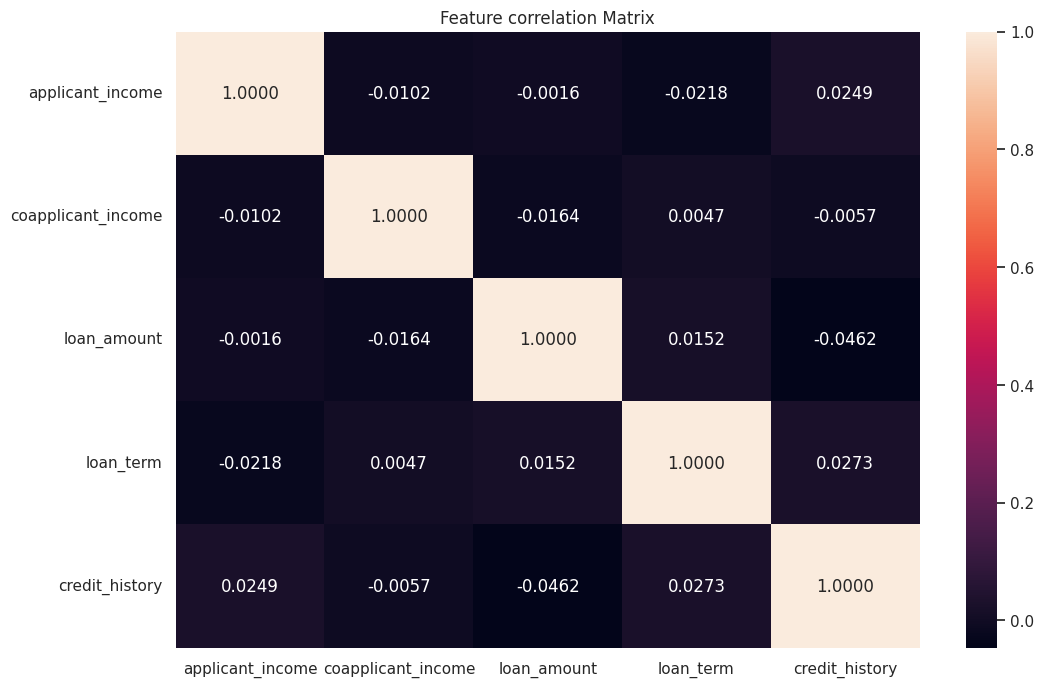

In [13]:
#====================================================
# Checking how feature are correlated with each other
#====================================================

plt.figure(figsize=(12,8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot= True, fmt=".4f")
plt.title("Feature correlation Matrix")
plt.show()

In [14]:
df.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_term',
       'credit_history', 'property_area', 'loan_status'],
      dtype='object')

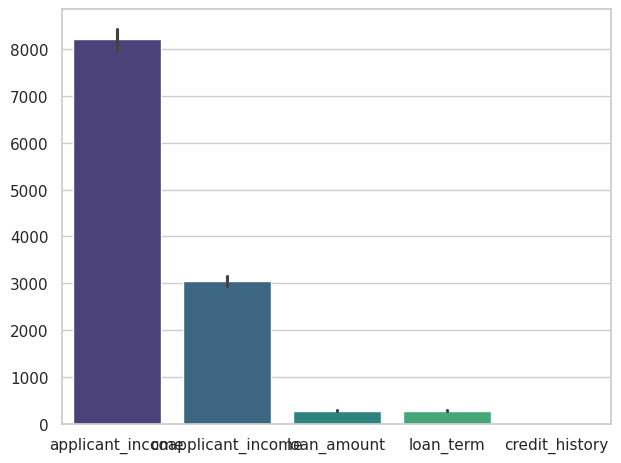

In [24]:
sns.barplot(data=df,palette='viridis')
plt.tight_layout()